# MNIST/CIFAR10 with 10-class output
Each output node is treated as a separate ReLU network

** Forked from `main_multihead.ipynb` on June 23, 2022

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import tqdm, utils, theory, data
from tabulate import tabulate
from numpy.linalg import inv as inv
import torch, pickle, os
import torch.nn.functional as F
import cluster_utils

%load_ext autoreload
%autoreload 2

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

P = 30
P_test = 1000
n_tasks = 2
sigma = 0.2
depth = 1
lambda_val = 100000000
n_epochs = 1
resample = False
fixed_w = 0
dataset = 'mnist'
permutation_ratios = torch.linspace(0, 1, 20)
NUM_SEEDS = 10
# permutation_ratios = [0]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Load loss/accuracy results from cluster outputs
Make sure the cluster results used the same parameters as above!!

In [16]:
# OR, load cluster results
batch_name = '2x30_mnist_1L_resample0_different_permutation'
local_path = '/Users/haozheshan/Dropbox/codes/gp_continual_learning/cluster_results'
organize_key = 'permutation'

organizer =\
    cluster_utils.ClusterResultOrganizer(local_path, batch_name=batch_name, max_ind=500)
organizer.load_all()

all_test_acc = organizer.organize_results('test acc', organize_key)
all_train_acc = organizer.organize_results('train acc', organize_key)
all_test_loss = organizer.organize_results('test loss', organize_key)
all_train_loss = organizer.organize_results('train loss', organize_key)

assert organizer.args.dataset == dataset
assert organizer.args.P == P
assert organizer.args.depth == depth

=================== Cluster organizer ===================
420 data objects loaded from folder "2x30_mnist_1L_resample0_different_permutation".
=================== Cluster organizer ===================


# 2. Plot value over keys (training/test acc/loss)

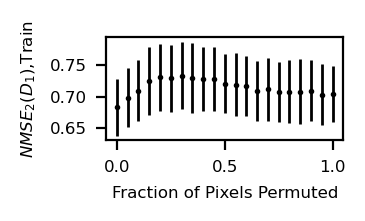

In [17]:
TASK_IND = 0
TIME_IND = 1
LOSS_NORMALIZATION = 10
VALUE_NAME = all_test_loss

def plot_value_over_keys(value):


    used_value = value
    plt.figure()
    for key in VALUE_NAME.keys():
        _data = VALUE_NAME[key] * LOSS_NORMALIZATION
        plt.errorbar(float(key), _data[:, 0, 1].mean(),
                     _data[:, 0, 1].std(0),
                     marker='o', color='k', markersize=1)


plot_value_over_keys(VALUE_NAME)
# plt.axhline(VALUE_NAME.mean(0)[0][TASK_IND, TASK_IND])
# plt.ylim(-0.01, 0.3)
plt.xlabel('Fraction of Pixels Permuted')
# plt.ylabel('Task1 Test Acc.')
plt.ylabel('${NMSE}_2(D_1)$,Train')
plt.xticks([0, 0.5, 1])
plt.tight_layout()
# plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

# 3. Compute forgetting coefficients etc.


In [18]:
NAIVE_GP = True
# compute forgetting coefficients etc.
mat_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
overlap_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
unoverlap_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
span_overlap_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
weight_covar = theory.compute_W_var(sigma**2, lambda_val, 2, False)
for seed in tqdm.trange(NUM_SEEDS):

    torch.manual_seed(seed)
    for perm_ind in range(len(permutation_ratios)):

        seq_of_train_x, _, seq_of_train_y_digit, _ = \
            data.prepare_sequential_dataset(n_tasks, P, P_test, dataset_name=dataset, resample=resample,
                                            permutation=permutation_ratios[perm_ind], data_path=None, n_epochs=n_epochs)
        for i in range(n_tasks):
            seq_of_train_x[i] = seq_of_train_x[i][torch.argsort(seq_of_train_y_digit[i])]
        seq_of_train_x = seq_of_train_x.double()

        if NAIVE_GP:
            k12 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[1], var1=torch.ones(1), depth=depth)
            k2 = theory.arccos_kernel_deep(seq_of_train_x[1], seq_of_train_x[1], var1=torch.ones(1), depth=depth)
            k1 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[0], var1=torch.ones(1), depth=depth)
            part1 = k12 @ theory.inverse(k2)
            part2 = torch.eye(P) - k12.T @ theory.inverse(k1)
        else:
            k12_2 = theory.cross_kernel_new(seq_of_train_x[0], seq_of_train_x[1], 1, 1, weight_covar, depth, lambda_val, sigma)
            k12_1 = theory.cross_kernel_new(seq_of_train_x[0], seq_of_train_x[1],
                                              0, 0, weight_covar, depth, lambda_val, sigma)
            # k12_1 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[1], var1=weight_covar[0, 0], depth=depth)
            k2 = theory.cross_kernel_new(seq_of_train_x[1], seq_of_train_x[1], 1, 1, weight_covar, depth, lambda_val, sigma)
            # k12 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[1], var1=torch.ones(1), depth=depth)
            # k2 = theory.arccos_kernel_deep(seq_of_train_x[1], seq_of_train_x[1], var1=torch.ones(1), depth=depth)
            k1 = theory.cross_kernel_new(seq_of_train_x[0], seq_of_train_x[0],
                                      0, 0, weight_covar, depth, lambda_val, sigma)
            part1 = k12_2 @ theory.inverse(k2)
            part2 = torch.eye(P) - k12_1.T @ theory.inverse(k1)
        mat = part1 @ part2
        mat_traces[seed, perm_ind] = torch.trace(mat.T @ mat) / P
        overlap_traces[seed, perm_ind] = torch.trace(part1.T @ part1) / P
        unoverlap_traces[seed, perm_ind] = torch.trace(part2.T @ part2) / P

        # _u, _s, _v = np.linalg.svd(k1)
        # k1_half_inv = torch.from_numpy(_u @ np.diag(_s**-0.5) @ _v)
        # span_overlap = k1_half_inv @ k12 @ theory.inverse(k2) @ k12.T @ k1_half_inv
        # span_overlap_traces[seed, perm_ind] = torch.trace(span_overlap) / P

  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:203: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:370: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 10/10 [00:11<00:00,  1.11s/it]


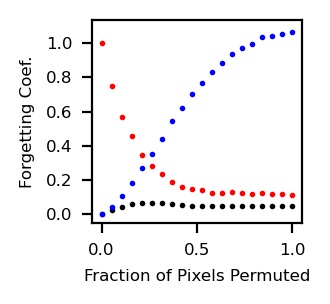

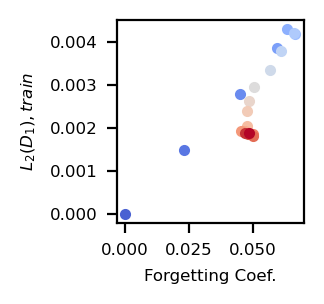

In [19]:

plt.figure(figsize=(1.6, 1.5))
plt.errorbar(permutation_ratios, mat_traces.mean(0), mat_traces.std(0),
             color='k', marker='o', markersize=1, lw=0)
plt.errorbar(permutation_ratios, overlap_traces.mean(0), overlap_traces.std(0),
             color='r', marker='o', markersize=1, lw=0)
plt.errorbar(permutation_ratios, unoverlap_traces.mean(0), unoverlap_traces.std(0),
             color='b', marker='o', markersize=1, lw=0)
plt.xlabel('Fraction of Pixels Permuted')
plt.ylabel('Forgetting Coef.')
# plt.ylim(-0.2, 2)
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


cmap = cm.coolwarm(np.linspace(0, 1, len(permutation_ratios) + 1))
plt.figure(figsize=(1.6, 1.5))
for i in range(len(permutation_ratios)):
    list_of_keys = list(all_train_loss.keys())
    plt.plot(mat_traces.mean(0)[i], all_train_loss[list_of_keys[i]][:, 0, 1].mean(0),
                 markersize=3, marker='o', color=cmap[i + 1])
# plt.xlim(0.015, 0.07)
# plt.ylim(0.001, 0.0045)
plt.xlabel('Forgetting Coef.')
# plt.plot(np.linspace(0, 2, 10), np.linspace(0, 2, 10) / 50, color='k', ls='--')
plt.ylabel('$L_2(D_1), train$')
plt.tight_layout()
# plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

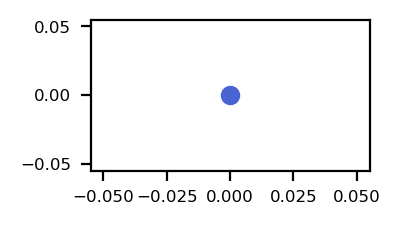

In [154]:
plt.scatter(0, 0, color=cmap[1])

(0.0, 1.0)

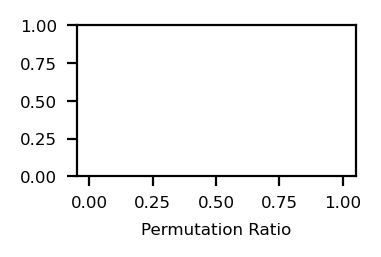

In [151]:
plt.figure()
plt.plot(permutation_ratios, span_overlap_traces.mean(0))
plt.xlabel('Permutation Ratio')
plt.ylim(0, 1)

# 4. Forgetting matrices at full permutation for different depths

In [110]:
# compute forgetting coefficients etc.
mat_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
overlap_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
unoverlap_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
span_overlap_traces = torch.zeros((NUM_SEEDS, len(permutation_ratios)))
weight_covar = theory.compute_W_var(sigma**2, lambda_val, 2, False)
for seed in tqdm.trange(NUM_SEEDS):

    torch.manual_seed(seed)
    for perm_ind in range(len(permutation_ratios)):

        seq_of_train_x, _, seq_of_train_y_digit, _ = \
            data.prepare_sequential_dataset(n_tasks, P, P_test, dataset_name=dataset, resample=resample,
                                            permutation=permutation_ratios[perm_ind], data_path=None, n_epochs=n_epochs)
        for i in range(n_tasks):
            seq_of_train_x[i] = seq_of_train_x[i][torch.argsort(seq_of_train_y_digit[i])]


        k12 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[1], var1=torch.ones(1), depth=depth)
        k2 = theory.arccos_kernel_deep(seq_of_train_x[1], seq_of_train_x[1], var1=torch.ones(1), depth=depth)
        k1 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[0], var1=torch.ones(1), depth=depth)
        part1 = k12 @ theory.inverse(k2)
        part2 = torch.eye(P) - k12.T @ theory.inverse(k1)
        mat = part1 @ part2
        mat_traces[seed, perm_ind] = torch.trace(mat.T @ mat) / P
        overlap_traces[seed, perm_ind] = torch.trace(part1.T @ part1) / P
        unoverlap_traces[seed, perm_ind] = torch.trace(part2.T @ part2) / P

        # _u, _s, _v = np.linalg.svd(k1)
        # k1_half_inv = torch.from_numpy(_u @ np.diag(_s**-0.5) @ _v)
        # span_overlap = k1_half_inv @ k12 @ theory.inverse(k2) @ k12.T @ k1_half_inv
        # span_overlap_traces[seed, perm_ind] = torch.trace(span_overlap) / P

  0%|          | 0/10 [00:00<?, ?it/s]

Files already downloaded and verified
Files already downloaded and verified


/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:370: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


  0%|          | 0/10 [00:12<?, ?it/s]


KeyboardInterrupt: 

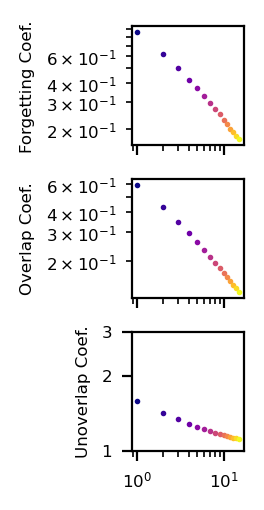

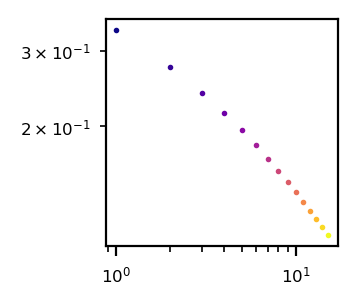

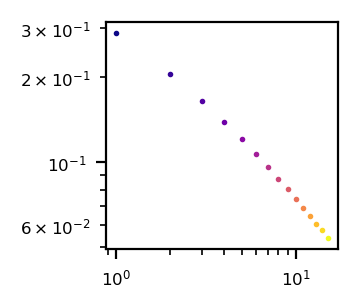

In [220]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.3, 2.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1


def loglog_plot(DATA_TO_PLOT):
    for i, _depth in enumerate(depths):
        plt.errorbar(_depth, DATA_TO_PLOT[:, i].mean().numpy(),
                     DATA_TO_PLOT[:, i].std().numpy() / np.sqrt(NUM_SEEDS),
                     marker='o', color=depth_cmap[i], markersize=1)
    plt.yscale('log')
    plt.xscale('log')

depth_cmap = cm.plasma(np.linspace(0, 1, len(depths)))

_, axes = plt.subplots(nrows=3, ncols=1, sharex=True)
axes = axes.ravel()

plt.sca(axes[0])
loglog_plot(mat_traces)
plt.ylabel('Forgetting Coef.')

plt.sca(axes[1])
loglog_plot(overlap_traces)
plt.ylabel('Overlap Coef.')

plt.sca(axes[2])
loglog_plot(unoverlap_traces)
plt.ylabel('Unoverlap Coef.')
plt.yticks([1, 2, 3], [1, 2, 3])


plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


plt.figure(figsize=(1.5, 1.5))
loglog_plot(span_overlap_traces)

plt.figure(figsize=(1.5, 1.5))
loglog_plot(r12_r21_traces)


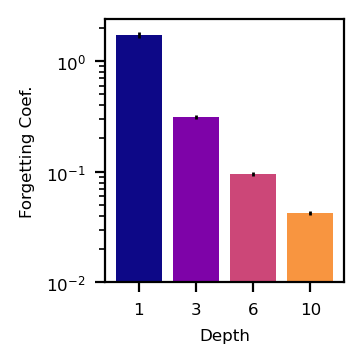

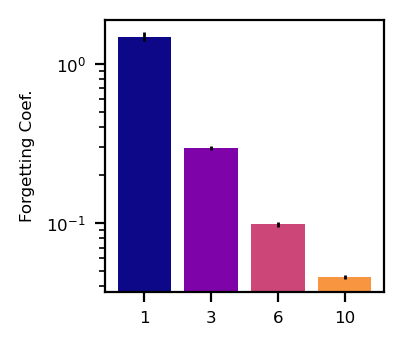

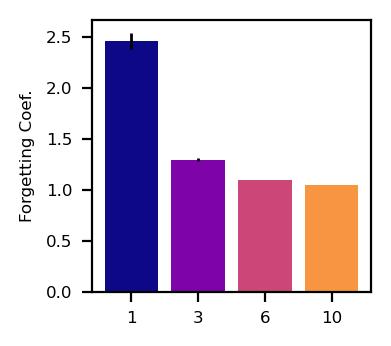

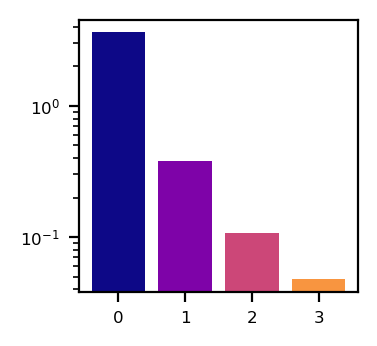

In [53]:
depth_cmap = cm.plasma(np.arange(4) / 4)
plt.figure()
for i in range(4):
    plt.bar(i, mat_traces.mean(0)[i], yerr=mat_traces.std(0)[i], color=depth_cmap[i], bottom=1e-2)
plt.yscale('log')
plt.ylabel('Forgetting Coef.')

plt.xticks(np.arange(4), [1, 3, 6, 10])
plt.xlabel('Depth')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


plt.figure()
for i in range(4):
    plt.bar(i, overlap_traces.mean(0)[i], yerr=overlap_traces.std(0)[i], color=depth_cmap[i])
plt.yscale('log')
plt.ylabel('Forgetting Coef.')
plt.xticks(np.arange(4), [1, 3, 6, 10])


plt.figure()
for i in range(4):
    plt.bar(i, unoverlap_traces.mean(0)[i], yerr=unoverlap_traces.std(0)[i], color=depth_cmap[i])
# plt.yscale('log')
plt.ylabel('Forgetting Coef.')
plt.xticks(np.arange(4), [1, 3, 6, 10])


plt.figure()
for i in range(4):
    plt.bar(i, unoverlap_traces.mean(0)[i] * overlap_traces.mean(0)[i], color=depth_cmap[i])
plt.yscale('log')

# 6. Toy 3D examples

In [29]:
u1 = np.array([1, 0, 0])
u2 = np.array([0, 1, 0])
u3 = np.array([0, 0, 1])

offsets = np.linspace(0.5, 6, 50)

# u1 = np.random.normal(np.zeros(3))
# u2 = np.random.normal(np.zeros(3))
# u3 = np.random.normal(np.zeros(3))

mean_angle = []
forgetting_coefs = []
losses = []
for offset in offsets:
    data_1 = np.array([offset * u1 + u3, offset * u1 - u2])
    # data_1 = np.array([offset * u1 + np.random.normal(np.zeros(3)), offset * u1 + np.random.normal(np.zeros(3))])
    # data_1[0] /= np.linalg.norm(data_1[0])
    # data_1[1] /= np.linalg.norm(data_1[1])
    data_2 = np.array([offset * u1 + u2, offset * u1 - u3])
    # data_2 = np.array([offset * u1 + np.random.normal(np.zeros(3)), offset * u1 + np.random.normal(np.zeros(3))])
    # data_2[0] /= np.linalg.norm(data_2[0])
    # data_2[1] /= np.linalg.norm(data_2[1])

    k12 = data_1 @ data_2.T
    k2 = data_2 @ data_2.T
    k1 = data_1 @ data_1.T
    r12 = k12 @ np.linalg.inv(k2)
    mat = k12 @ np.linalg.inv(k2) @ (np.eye(2) - k12.T @ np.linalg.inv(k1))
    angles = k12 / np.sqrt(np.diag(k1).reshape(-1, 1) @ np.diag(k2).reshape(1, -1))
    mean_angle.append(angles.mean())
    forgetting = np.linalg.norm(mat @ np.array([[1], [0]]))**2
    forgetting_coefs.append(np.trace(mat.T @ mat) / 2)
    losses.append(forgetting / 2)
    # plt.scatter(offset, forgetting, color='b')
    # plt.scatter(offset, k12.mean() / np.linalg.norm(data_1)**2 * 2,  color='k')
    # plt.scatter(offset, np.trace(r12.T @ r12), color='k')



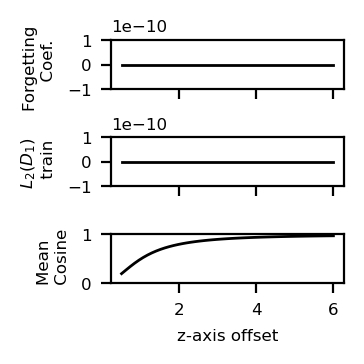

In [16]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.8]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)
axes = axes.ravel()
plt.sca(axes[0])
plt.plot(offsets, forgetting_coefs, color='k')
plt.ylim(-1e-10, 1e-10)
plt.ylabel('Forgetting \n  Coef.')
# plt.xlabel('z-axis offset')

plt.sca(axes[1])
plt.plot(offsets, losses, color='k')
plt.ylim(-1e-10, 1e-10)
plt.ylabel('$L_2(D_1)$ \n train')
# plt.xlabel('z-axis offset')

plt.sca(axes[2])
plt.plot(offsets, mean_angle, color='k')
plt.ylim(0, 1)
plt.ylabel('Mean \n Cosine')
plt.xlabel('z-axis offset')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

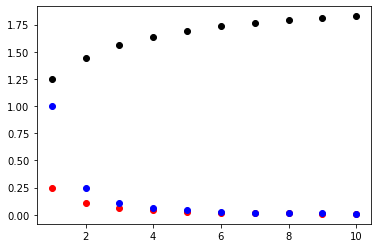

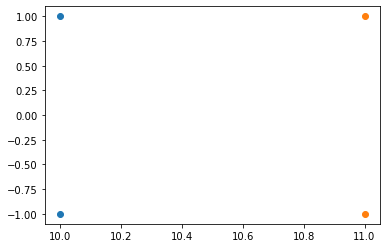

In [11]:
plt.figure()
for offset in np.arange(1, 11):
    data_1 = np.array([[offset, -1], [offset, 1]])
    # data_1 = np.array([offset * u1 + np.random.normal(np.zeros(3)), offset * u1 + np.random.normal(np.zeros(3))])
    # data_1[0] /= np.linalg.norm(data_1[0])
    # data_1[1] /= np.linalg.norm(data_1[1])
    data_2 = np.array([[offset + 1, -1], [offset + 1, 1]])
    # data_2 = np.array([offset * u1 + np.random.normal(np.zeros(3)), offset * u1 + np.random.normal(np.zeros(3))])
    # data_2[0] /= np.linalg.norm(data_2[0])
    # data_2[1] /= np.linalg.norm(data_2[1])

    k12 = data_1 @ data_2.T
    k2 = data_2 @ data_2.T
    k1 = data_1 @ data_1.T
    r12 = k12 @ np.linalg.inv(k2)
    second_part = np.eye(2) - k12.T @ np.linalg.inv(k1)
    mat = r12 @ second_part
    angles = k12 / np.sqrt(np.diag(k1).reshape(-1, 1) @ np.diag(k2).reshape(1, -1))
    # mean_angle.append(angles.mean())
    forgetting = np.linalg.norm(mat @ np.array([[1], [-1]]))**2
    # plt.scatter(offset, forgetting, color='b')
    # plt.scatter(offset, k12.mean() / np.linalg.norm(data_1)**2 * 2,  color='k')
    plt.scatter(offset, np.trace(mat.T @ mat), color='r')
    plt.scatter(offset, np.trace(r12.T @ r12), color='k')
    plt.scatter(offset, np.trace(second_part.T @ second_part), color='b')


plt.figure()
plt.scatter(data_1[:, 0], data_1[:, 1])
plt.scatter(data_2[:, 0], data_2[:, 1])

(0.5, 0.8)

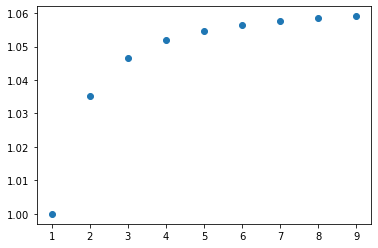

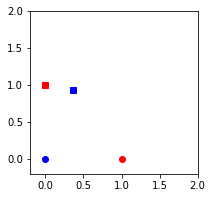

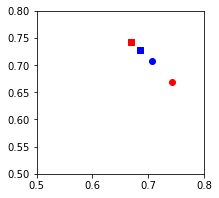

In [154]:

dim = 2
points = np.random.normal(np.zeros((dim * 2, dim)))
points[points < 0] = 0
for i in range(4):
    points[i] /= np.linalg.norm(points[i]) + 1e-10

# for i in range(4):
#     points[i] -= points[i].mean()
series = []
for offset in np.arange(1, 10):
    data_1 = offset + points[:dim, :]
    data_1[0] /= np.linalg.norm(data_1[0])
    data_1[1] /= np.linalg.norm(data_1[1])
    data_2 = offset + points[dim:, :]
    data_2[0] /= np.linalg.norm(data_2[0])
    data_2[1] /= np.linalg.norm(data_2[1])
    # data_2 = np.array([offset * u1 + np.random.normal(np.zeros(3)), offset * u1 + np.random.normal(np.zeros(3))])
    # data_2[0] /= np.linalg.norm(data_2[0])
    # data_2[1] /= np.linalg.norm(data_2[1])

    k12 = data_1 @ data_2.T
    k2 = data_2 @ data_2.T
    k1 = data_1 @ data_1.T
    r12 = k12 @ np.linalg.inv(k2)
    second_part = np.eye(dim) - k12.T @ np.linalg.inv(k1)
    mat = r12 @ second_part
    angles = k12 / np.sqrt(np.diag(k1).reshape(-1, 1) @ np.diag(k2).reshape(1, -1))
    # mean_angle.append(angles.mean())
    # forgetting = np.linalg.norm(mat @ np.array([[1], [-1]]))**2
    # plt.scatter(offset, forgetting, color='b')
    # plt.scatter(offset, k12.mean() / np.linalg.norm(data_1)**2 * 2,  color='k')
    series.append(np.trace(mat.T @ mat) / dim)

    # plt.scatter(offset, np.trace(r12.T @ r12), color='k')
    # plt.scatter(offset, np.trace(second_part.T @ second_part), color='b')

plt.figure()
plt.scatter(np.arange(1, 10), np.array(series) / series[0])

plt.figure(figsize=(3, 3))
plt.scatter(points[0, 0], points[0, 1], color='r', marker='s')
plt.scatter(points[1, 0], points[1, 1], color='b', marker='s')
plt.scatter(points[2, 0], points[2, 1], color='r')
plt.scatter(points[3, 0], points[3, 1], color='b')
plt.xlim(-0.2, 2)
plt.ylim(-0.2, 2)


plt.figure(figsize=(3, 3))
plt.scatter(data_1[0, 0], data_1[0, 1], color='r', marker='s')
plt.scatter(data_1[1, 0], data_1[1, 1], color='b', marker='s')
plt.scatter(data_2[0, 0], data_2[0, 1], color='r')
plt.scatter(data_2[1, 0], data_2[1, 1], color='b')
plt.xlim(0.5, 0.8)
plt.ylim(0.5, 0.8)

In [10]:
a = np.random.normal(np.zeros(2))
b = np.random.normal(np.zeros(2))
for i in range(10):
    a_new = (a + i) / np.linalg.norm(a + i)
    b_new = (b + i) / np.linalg.norm(b + i)
    print(utils.cos(a_new, b_new) * (1 - utils.cos(a_new, b_new)))

[[-1.98872134]]
[[0.05946249]]
[[0.0127738]]
[[0.00595695]]
[[0.00351268]]
[[0.0023322]]
[[0.00166604]]
[[0.00125147]]
[[0.00097532]]
[[0.00078188]]


# 7. Permuted batch

In [16]:
# all_tr_loss = torch.zeros((NUM_SEEDS, len(permutation_ratios), n_tasks, n_tasks))
all_te_loss = torch.zeros((NUM_SEEDS, len(permutation_ratios), n_tasks, n_tasks))
# all_tr_acc = torch.zeros((NUM_SEEDS, len(permutation_ratios), n_tasks, n_tasks))
all_te_acc = torch.zeros((NUM_SEEDS, len(permutation_ratios), n_tasks, n_tasks))

single_task_te_loss = torch.zeros((NUM_SEEDS))

for seed in tqdm.trange(NUM_SEEDS):

    torch.manual_seed(seed)
    for perm_ind in range(len(permutation_ratios)):

        seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
            data.prepare_sequential_dataset(2, 5000, P_test, dataset_name=dataset, resample=True,
                                            permutation=permutation_ratios[perm_ind], data_path=None, n_epochs=n_epochs)

        if perm_ind == 0:
            te_acc, te_loss = theory.multihead_one_task_accuracy(seq_of_train_x[0],
                                                                 seq_of_test_x[0],
                                                                 seq_of_train_y_digit[0],
                                                                 seq_of_test_y_digit[0], depth=depth)
            single_task_te_loss[seed] = te_loss

        batch_train_x = seq_of_train_x.reshape(-1, seq_of_train_x.shape[-1])
        doubled_seq_x = torch.vstack([batch_train_x[None, :, :], batch_train_x[None, :, :]])
        batch_train_y_digits = seq_of_train_y_digit.flatten()
        doubled_seq_y = torch.vstack([batch_train_y_digits, batch_train_y_digits])

        batch_te_acc, batch_te_loss = theory.multihead_one_task_accuracy(batch_train_x,
                                                                 seq_of_test_x[0],
                                                                 batch_train_y_digits,
                                                                 seq_of_test_y_digit[0], depth=depth)

        all_te_loss[seed, perm_ind, 0, 0] = batch_te_loss
        all_te_acc[seed, perm_ind, 0, 0] = batch_te_acc
        # all_tr_acc = torch.zeros((NUM_SEEDS, len(permutation_ratios), n_tasks, n_tasks))
        # all_te_acc = torch.zeros((NUM_SEEDS, len(permutation_ratios), n_tasks, n_tasks))
        #
        #
        #
        # single_seed_train_accuracy, single_seed_test_accuracy, single_seed_train_loss, single_seed_test_loss = \
        #     data.get_multihead_accuracy(seq_of_train_x=doubled_seq_x, seq_of_test_x=seq_of_test_x,
        #                                 seq_of_train_y_digit=doubled_seq_y, seq_of_test_y_digit=seq_of_test_y_digit,
        #                                 sigma=sigma, lamb=lambda_val,
        #                                 fixed_w=bool(fixed_w), depth=depth,
        #                                 write_fn=None,
        #                                 tqdm_disable=True)
        # print(batch_te_loss)
        # print(single_seed_test_loss[0, 0])
        #
        # all_tr_loss[seed, perm_ind] = single_seed_train_loss
        # all_te_loss[seed, perm_ind] = single_seed_test_loss
        # all_tr_acc[seed, perm_ind] = single_seed_train_accuracy
        # all_te_acc[seed, perm_ind] = single_seed_test_accuracy


  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:326: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  def arccos_kernel_deep(x1, x2, var1=None, var2=None, covar=None, depth=0):
100%|██████████| 10/10 [01:55<00:00, 11.51s/it]


Text(0.5, 0, 'permutation ratio')

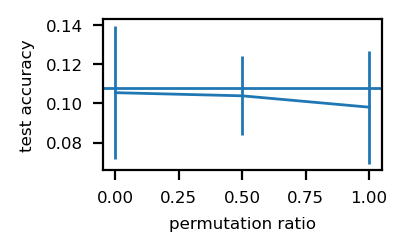

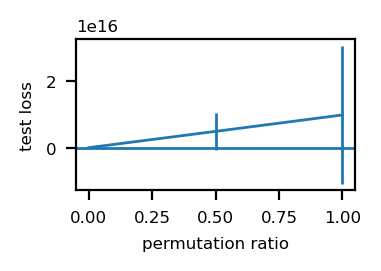

In [15]:
plt.figure()
plt.errorbar(permutation_ratios, all_te_acc.mean(0)[:, 0, 0], all_te_acc.std(0)[:, 0, 0])
plt.axhline(te_acc)
plt.ylabel('test accuracy')
plt.xlabel('permutation ratio')


plt.figure()
plt.errorbar(permutation_ratios, all_te_loss.mean(0)[:, 0, 0], all_te_loss.std(0)[:, 0, 0])
plt.axhline(te_loss)
plt.ylabel('test loss')
plt.xlabel('permutation ratio')